In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from six.moves import urllib

from sqlalchemy import create_engine
import plotly.express as px

import os
import warnings
warnings.filterwarnings("ignore")


In [5]:
data_dir="./data/"
data_url = "https://raw.githubusercontent.com/mohitmahiyt/cardataset/refs/heads/main/cars_dataset.csv"
os.makedirs(data_dir, exist_ok=True)

filename = os.path.basename(data_url)
print(filename)

filepath = os.path.join(data_dir,filename)
print(filepath)

urllib.request.urlretrieve(data_url, filepath)

cars_dataset.csv
./data/cars_dataset.csv


('./data/cars_dataset.csv', <http.client.HTTPMessage at 0x1f68969f390>)

In [6]:
#data cleaning

In [7]:
df = pd.read_csv("./data/cars_dataset.csv" , header=11)
df

,NaN,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,1.0,Maruti Alto,Maruti,Alto,9.0,53800.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,235000.0,NaN
1,2.0,Maruti Alto,Maruti,Alto,11.0,11000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,185000.0,NaN
2,3.0,Maruti Alto,Maruti,Alto,11.0,80000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,150000.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15796,30016.0,Bentley Continental,Bentley,Continental,10.0,30000.0,Dealer,Petrol,Automatic,8.60,5998.0,552.0,4.0,8100000.0,NaN
15797,30017.0,Rolls-Royce Ghost,Rolls-Royce,Ghost,4.0,5000.0,Individual,Petrol,Automatic,10.20,6592.0,563.0,4.0,24200000.0,NaN
15798,30018.0,Bentley Continental,Bentley,Continental,9.0,37500.0,Dealer,Petrol,Automatic,6.00,5998.0,600.0,5.0,5200000.0,NaN
15799,30019.0,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2.0,3800.0,Dealer,Petrol,Automatic,4.00,3855.0,601.0,4.0,39500000.0,NaN


In [8]:
df.isnull().sum()

NaN                    390
car_name               390
brand                  390
model                  390
vehicle_age            390
km_driven              390
seller_type            390
fuel_type              390
transmission_type      390
mileage                390
engine                 390
max_power              390
seats                  390
selling_price          390
 my_car              15801
dtype: int64

In [9]:
df.columns

Index(['NaN', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price', ' my_car'],
      dtype='str')

In [10]:
#df.drop(" my_car" , axis=1 )

In [11]:
df

,NaN,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,1.0,Maruti Alto,Maruti,Alto,9.0,53800.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,235000.0,NaN
1,2.0,Maruti Alto,Maruti,Alto,11.0,11000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,185000.0,NaN
2,3.0,Maruti Alto,Maruti,Alto,11.0,80000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,150000.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15796,30016.0,Bentley Continental,Bentley,Continental,10.0,30000.0,Dealer,Petrol,Automatic,8.60,5998.0,552.0,4.0,8100000.0,NaN
15797,30017.0,Rolls-Royce Ghost,Rolls-Royce,Ghost,4.0,5000.0,Individual,Petrol,Automatic,10.20,6592.0,563.0,4.0,24200000.0,NaN
15798,30018.0,Bentley Continental,Bentley,Continental,9.0,37500.0,Dealer,Petrol,Automatic,6.00,5998.0,600.0,5.0,5200000.0,NaN
15799,30019.0,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2.0,3800.0,Dealer,Petrol,Automatic,4.00,3855.0,601.0,4.0,39500000.0,NaN


In [12]:
#df.drop(" my_car" , axis=1 , inplace=True)

In [13]:
df[df.isna().all(axis=1)]

,NaN,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.dropna(how="all" ,inplace=True)

In [15]:
df.isnull().sum()

NaN                      0
car_name                 0
brand                    0
model                    0
vehicle_age              0
km_driven                0
seller_type              0
fuel_type                0
transmission_type        0
mileage                  0
engine                   0
max_power                0
seats                    0
selling_price            0
 my_car              15411
dtype: int64

In [16]:
df

,NaN,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,1.0,Maruti Alto,Maruti,Alto,9.0,53800.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,235000.0,NaN
1,2.0,Maruti Alto,Maruti,Alto,11.0,11000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,185000.0,NaN
2,3.0,Maruti Alto,Maruti,Alto,11.0,80000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,150000.0,NaN
7,4.0,Maruti Alto,Maruti,Alto,10.0,57000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,172000.0,NaN
8,5.0,Maruti Alto,Maruti,Alto,11.0,72000.0,Individual,CNG,Manual,26.83,796.0,38.4,5.0,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15796,30016.0,Bentley Continental,Bentley,Continental,10.0,30000.0,Dealer,Petrol,Automatic,8.60,5998.0,552.0,4.0,8100000.0,NaN
15797,30017.0,Rolls-Royce Ghost,Rolls-Royce,Ghost,4.0,5000.0,Individual,Petrol,Automatic,10.20,6592.0,563.0,4.0,24200000.0,NaN
15798,30018.0,Bentley Continental,Bentley,Continental,9.0,37500.0,Dealer,Petrol,Automatic,6.00,5998.0,600.0,5.0,5200000.0,NaN
15799,30019.0,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2.0,3800.0,Dealer,Petrol,Automatic,4.00,3855.0,601.0,4.0,39500000.0,NaN


In [17]:
df.drop("NaN" , axis =1 , inplace=True)

In [18]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9.0,53800.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11.0,11000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11.0,80000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,150000.0,NaN
7,Maruti Alto,Maruti,Alto,10.0,57000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,172000.0,NaN
8,Maruti Alto,Maruti,Alto,11.0,72000.0,Individual,CNG,Manual,26.83,796.0,38.4,5.0,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15796,Bentley Continental,Bentley,Continental,10.0,30000.0,Dealer,Petrol,Automatic,8.60,5998.0,552.0,4.0,8100000.0,NaN
15797,Rolls-Royce Ghost,Rolls-Royce,Ghost,4.0,5000.0,Individual,Petrol,Automatic,10.20,6592.0,563.0,4.0,24200000.0,NaN
15798,Bentley Continental,Bentley,Continental,9.0,37500.0,Dealer,Petrol,Automatic,6.00,5998.0,600.0,5.0,5200000.0,NaN
15799,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2.0,3800.0,Dealer,Petrol,Automatic,4.00,3855.0,601.0,4.0,39500000.0,NaN


In [19]:
df.reset_index(drop=True, inplace=True)

In [20]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9.0,53800.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11.0,11000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11.0,80000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10.0,57000.0,Dealer,CNG,Manual,26.83,796.0,38.4,5.0,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11.0,72000.0,Individual,CNG,Manual,26.83,796.0,38.4,5.0,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Bentley Continental,Bentley,Continental,10.0,30000.0,Dealer,Petrol,Automatic,8.60,5998.0,552.0,4.0,8100000.0,NaN
15407,Rolls-Royce Ghost,Rolls-Royce,Ghost,4.0,5000.0,Individual,Petrol,Automatic,10.20,6592.0,563.0,4.0,24200000.0,NaN
15408,Bentley Continental,Bentley,Continental,9.0,37500.0,Dealer,Petrol,Automatic,6.00,5998.0,600.0,5.0,5200000.0,NaN
15409,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2.0,3800.0,Dealer,Petrol,Automatic,4.00,3855.0,601.0,4.0,39500000.0,NaN


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  float64
 4   km_driven          15411 non-null  float64
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  float64
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  float64
 12  selling_price      15411 non-null  float64
 13   my_car            0 non-null      float64
dtypes: float64(8), str(6)
memory usage: 2.3 MB


In [22]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price', ' my_car'],
      dtype='str')

In [23]:
df[["vehicle_age","km_driven","engine","seats"]]=df[["vehicle_age","km_driven","engine","seats"]].astype(int)

In [24]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Bentley Continental,Bentley,Continental,10,30000,Dealer,Petrol,Automatic,8.60,5998,552.0,4,8100000.0,NaN
15407,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.20,6592,563.0,4,24200000.0,NaN
15408,Bentley Continental,Bentley,Continental,9,37500,Dealer,Petrol,Automatic,6.00,5998,600.0,5,5200000.0,NaN
15409,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.0,4,39500000.0,NaN


In [25]:
df[df.duplicated(subset=df.columns)]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
160,Maruti Alto,Maruti,Alto,9,70000,Individual,Petrol,Manual,19.70,796,46.30,5,200000.0,NaN
203,Maruti Alto,Maruti,Alto,11,70000,Individual,Petrol,Manual,19.70,796,46.30,5,135000.0,NaN
386,Maruti Alto,Maruti,Alto,3,20000,Individual,Petrol,Manual,24.70,796,47.30,5,310000.0,NaN
408,Maruti Alto,Maruti,Alto,7,35000,Individual,Petrol,Manual,22.74,796,47.30,5,250000.0,NaN
409,Maruti Alto,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.70,796,47.30,5,310000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14953,Ford Endeavour,Ford,Endeavour,4,43000,Dealer,Diesel,Automatic,10.91,3198,197.00,7,2875000.0,NaN
15081,Lexus ES,Lexus,ES,4,33000,Dealer,Petrol,Automatic,22.37,2487,214.56,5,4100000.0,NaN
15286,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993,261.40,4,5600000.0,NaN
15364,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.00,5,750000.0,NaN


In [26]:
df[df["car_name"]=="Maruti Alto"]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,Maruti Alto,Maruti,Alto,6,70000,Individual,Petrol,Manual,23.95,998,67.1,5,300000.0,NaN
2325,Maruti Alto,Maruti,Alto,8,90000,Individual,Petrol,Manual,20.92,998,67.1,5,220000.0,NaN
2326,Maruti Alto,Maruti,Alto,9,15000,Individual,Petrol,Manual,20.92,998,67.1,5,220000.0,NaN
2327,Maruti Alto,Maruti,Alto,9,42489,Trustmark Dealer,Petrol,Manual,20.92,998,67.1,5,235000.0,NaN


In [27]:
df[df["car_name"]=="Maruti Alto"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2324    False
2325    False
2326    False
2327    False
2328    False
Length: 778, dtype: bool

In [28]:
df.duplicated().sum()

np.int64(167)

In [29]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Bentley Continental,Bentley,Continental,10,30000,Dealer,Petrol,Automatic,8.60,5998,552.0,4,8100000.0,NaN
15407,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.20,6592,563.0,4,24200000.0,NaN
15408,Bentley Continental,Bentley,Continental,9,37500,Dealer,Petrol,Automatic,6.00,5998,600.0,5,5200000.0,NaN
15409,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.0,4,39500000.0,NaN


In [30]:
df[df.duplicated(keep=False)]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
122,Maruti Alto,Maruti,Alto,9,70000,Individual,Petrol,Manual,19.70,796,46.3,5,200000.0,NaN
132,Maruti Alto,Maruti,Alto,11,70000,Individual,Petrol,Manual,19.70,796,46.3,5,135000.0,NaN
160,Maruti Alto,Maruti,Alto,9,70000,Individual,Petrol,Manual,19.70,796,46.3,5,200000.0,NaN
203,Maruti Alto,Maruti,Alto,11,70000,Individual,Petrol,Manual,19.70,796,46.3,5,135000.0,NaN
351,Maruti Alto,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.70,796,47.3,5,310000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15286,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993,261.4,4,5600000.0,NaN
15361,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.0,5,750000.0,NaN
15364,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.0,5,750000.0,NaN
15390,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,13,72000,Dealer,Petrol,Automatic,10.13,3498,364.9,5,999000.0,NaN


In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Bentley Continental,Bentley,Continental,10,30000,Dealer,Petrol,Automatic,8.60,5998,552.0,4,8100000.0,NaN
15407,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.20,6592,563.0,4,24200000.0,NaN
15408,Bentley Continental,Bentley,Continental,9,37500,Dealer,Petrol,Automatic,6.00,5998,600.0,5,5200000.0,NaN
15409,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.0,4,39500000.0,NaN


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.reset_index(drop=True)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,my_car
0,Maruti Alto,Maruti,Alto,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000.0,NaN
1,Maruti Alto,Maruti,Alto,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000.0,NaN
2,Maruti Alto,Maruti,Alto,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000.0,NaN
3,Maruti Alto,Maruti,Alto,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000.0,NaN
4,Maruti Alto,Maruti,Alto,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15239,Bentley Continental,Bentley,Continental,10,30000,Dealer,Petrol,Automatic,8.60,5998,552.0,4,8100000.0,NaN
15240,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.20,6592,563.0,4,24200000.0,NaN
15241,Bentley Continental,Bentley,Continental,9,37500,Dealer,Petrol,Automatic,6.00,5998,600.0,5,5200000.0,NaN
15242,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.0,4,39500000.0,NaN


In [35]:
df.to_csv("./data/cleaned_cars_dataset.csv", index=False)

Save data in SQL

EDA

In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  str    
 1   brand              15244 non-null  str    
 2   model              15244 non-null  str    
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  str    
 6   fuel_type          15244 non-null  str    
 7   transmission_type  15244 non-null  str    
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  float64
 13   my_car            0 non-null      float64
dtypes: float64(4), int64(4), str(6)
memory usage: 2.4 MB


In [37]:
# splitting numerical and catergorical columns

In [38]:
df["max_power"].dtypes

dtype('float64')

In [39]:
df["brand"].dtypes

<StringDtype(na_value=nan)>

In [40]:
df["seats"].dtype != "O"

True

In [41]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price', ' my_car'],
      dtype='str')

In [45]:
numerical_features = [feature for feature in df.columns  if df[feature].dtypes !='O']
categorical_features = [feature for feature in df.columns  if df[feature].dtypes =='O']

print(f"There are {len(numerical_features)} numerical features named: {numerical_features}")
print(f"There are {len(categorical_features)} categorical features named: {categorical_features}")

There are 14 numerical features named: ['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', ' my_car']
There are 0 categorical features named: []


In [43]:
categorical_features

[]

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

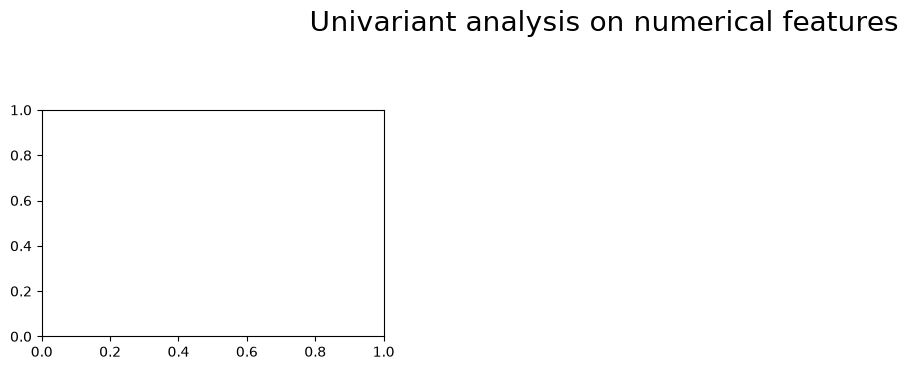

In [46]:
# Univariant Analysis
# numerical features

plt.figure(figsize=(15,10))
plt.suptitle("Univariant analysis on numerical features", fontsize=20)
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x = df[numerical_features[i]], shade=True, color='r')
    plt.tight_layout()

In [47]:
# univariant analysis
# numerical feature

plt.figure(figsize=(15,10))
plt.suptitle("Outlier  numerical features" , frontsize=20)
for i in range(len(numerical_feature)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x = df[numerical_feature[i]], shade=True , color="r")
    plt.tight_layout()
    

AttributeError: 'Text' object has no property 'frontsize'

<Figure size 1500x1000 with 0 Axes>